# **EEG Feature Engineering Framework**  


While the first project sets up the foundation by creating clean, preprocessed epochs from raw EEG data, this script is the **next step in the pipeline**. It focuses on extracting meaningful features from those epochs for downstream analysis.

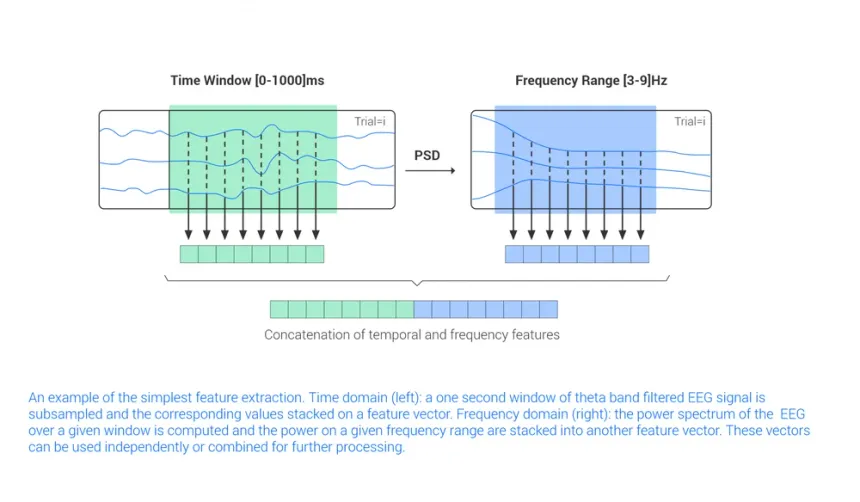

---

### **Key Features of This Script:**  

1. **Loading Preprocessed Data**:  
   The script loads the `.fif` files from the previous project, which contain the cleaned and segmented EEG epochs. It makes it easy to access these files for further analysis.

2. **Feature Extraction**:
   - **Power Spectral Density (PSD)**:  
     The script calculates the PSD using Welch's method, which turns the time-domain EEG data into frequency-domain data. This is useful for studying brain waves.
   - **Frequency Bands**:  
     The script divides the PSD values into standard frequency bands (Delta, Theta, Alpha, Beta, Gamma), which help in understanding different types of brain activity.
   - **Event-Specific Features**:  
     PSD features are extracted separately for different events, allowing you to compare or classify brain activity related to specific events or conditions.
   - **Reshaping Data for Machine Learning**:  
     The extracted features are organized into a wide-format table, with features like `"Electrode x Frequency Band"`. This format is ideal for machine learning models.

3. **Integration with Metadata**:  
   The script combines EEG features with metadata (like subject IDs and event labels), creating a complete dataset ready for analysis.

4. **Saving the Data**:  
   After processing, the script saves the final datasets, so you can easily use them in future analyses or machine learning tasks.

---


## **Importing Libraries**

In [8]:
import os
from pathlib import Path
import pywt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import mne
from mne.io import Raw
from mne import Epochs, find_events, pick_types
from mne.filter import filter_data
from mne.time_frequency import psd_array_welch
from mne_connectivity import spectral_connectivity_epochs
from tensorpac import Pac


# Set log-level to reduce verbosity
mne.set_log_level("WARNING")

## **Loading Data**

In [9]:
# Load participants.tsv
participants_file = 'ds005545-download/participants.tsv'
participants_data = pd.read_csv(participants_file, sep='\t')

# Display the first few rows
participants_data.head()


,participant_id,age,sex,handedness
0,sub-01,16,M,Rt
1,sub-02,17,F,Rt
2,sub-03,15,F,Rt
3,sub-04,14,M,Rt
4,sub-05,16,F,Rt


In [10]:
# Directory where preprocessed `.fif` files are stored
SAVE_DIR = "processed_epochs"  # Update to your save directory

def load_epochs(subject_id, save_dir=SAVE_DIR):
    """
    Load all `.fif` files for a specific subject.

    Parameters:
    - subject_id: The subject identifier (e.g., 'sub-01').
    - save_dir: The base directory containing processed `.fif` files.

    Returns:
    - epochs_list: List of mne.Epochs objects for the subject.
    """
    subject_path = Path(save_dir) / subject_id
    if not subject_path.exists():
        raise FileNotFoundError(f"Directory for {subject_id} not found in {save_dir}!")

    # Find all `.fif` files in the subject's directory
    fif_files = sorted(subject_path.glob("*_processed-epo.fif"))
    if not fif_files:
        raise FileNotFoundError(f"No `.fif` files found for {subject_id} in {subject_path}.")

    # Load each `.fif` file into an mne.Epochs object
    epochs_list = [mne.read_epochs(str(f), preload=True) for f in fif_files]
    print(f"Loaded {len(epochs_list)} `.fif` files for {subject_id}.")
    return epochs_list

In [11]:
# Example usage
subject_id = "sub-01"  # Replace with the subject ID you want to load
epochs_01 = load_epochs(subject_id)



Loaded 3 `.fif` files for sub-01.


## **Extracting Events**

In [13]:

def get_events_from_epochs(epochs):
    """
    Retrieve events and event IDs from an mne.Epochs object.
    
    Parameters:
    - epochs: An mne.Epochs object.
    
    Returns:
    - events: The events array (shape: n_events x 3).
    - event_id: A dictionary mapping event names to event IDs.
    """
    events = epochs.events  # Shape: (n_events, 3)
    event_id = epochs.event_id  # Dictionary: {event_name: event_code}
    return events, event_id

# Retrieve events for each epochs file
for i, epochs in enumerate(epochs_01):
    print(f"File {i + 1}:")
    events, event_id = get_events_from_epochs(epochs)
    print(f"  Events shape: {events.shape}")
    print(f"  Event IDs: {event_id}")


File 1:
  Events shape: (183, 3)
  Event IDs: {'Trigger-401': 1, 'Trigger-402': 2, 'Trigger-501': 3}
File 2:
  Events shape: (183, 3)
  Event IDs: {'Trigger-401': 1, 'Trigger-402': 2, 'Trigger-501': 3}
File 3:
  Events shape: (183, 3)
  Event IDs: {'Trigger-401': 1, 'Trigger-402': 2, 'Trigger-501': 3}


In [14]:
# Epochs_data is a 3D array of dimension (239 epochs, 306 channels, 106 time instants).
epochs_data = epochs.get_data()
type(epochs_data), epochs_data.shape

(numpy.ndarray, (183, 58, 701))

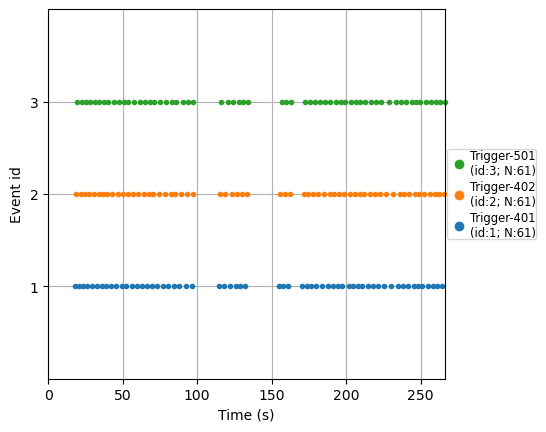

In [15]:
# Extract events 

event1 = 'Trigger-401'
event2 = 'Trigger-402'
event3 = 'Trigger-501'

sfreq = epochs.info['sfreq']


fig = mne.viz.plot_events(events, sfreq=sfreq, event_id=event_id);

## **Electrode positions**

In [16]:
# Load electrode metadata
electrodes_tsv = 'ds005545-download/sub-80/ses-01/ieeg/sub-80_ses-01_electrodes.tsv'
electrode_positions = pd.read_csv(electrodes_tsv, sep='\t')

# Display electrode positions
print(electrode_positions.head())

  name          x          y          z  size
0   A3 -50.106579 -58.395985  23.277752     0
1   A4 -59.254402 -54.785877  15.215353     0
2   A5 -59.978233 -40.066578  39.257343     0
3   A6 -45.325970 -28.038254  37.129173     0
4   A7 -54.598400 -25.692129  44.675392     0


## **Subject IDs**

In [ ]:
# Get the list of subject directories
save_path = Path(SAVE_DIR)
subject_dirs = [item.name for item in save_path.iterdir() if item.is_dir()]

# Set the subject
print(f"Subjects found in '{SAVE_DIR}': {len(subject_dirs)}")
print(subject_dirs)


Subjects found in 'processed_epochs': 40
['sub-01', 'sub-02', 'sub-03', 'sub-04', 'sub-05', 'sub-06', 'sub-07', 'sub-08', 'sub-09', 'sub-10', 'sub-100', 'sub-101', 'sub-102', 'sub-103', 'sub-104', 'sub-105', 'sub-106', 'sub-11', 'sub-12', 'sub-13', 'sub-14', 'sub-15', 'sub-16', 'sub-17', 'sub-18', 'sub-19', 'sub-20', 'sub-21', 'sub-22', 'sub-23', 'sub-24', 'sub-25', 'sub-26', 'sub-27', 'sub-28', 'sub-29', 'sub-30', 'sub-31', 'sub-32', 'sub-33']


## **Epochs to dataframe**


This function converts EEG epochs into a structured pandas DataFrame, flattening the data into time-by-channel features and assigning labels based on event conditions. It supports optional EEG channel selection and includes subject metadata if provided. 

Key steps:
1. Extracts EEG data from the epochs.
2. Flattens the epochs into a 2D array (samples × features).
3. Labels the data based on specified event conditions (e.g., `'Trigger-401'`).
4. Returns a DataFrame with the EEG data and corresponding labels.



In [18]:
def preprocess_epochs_to_dataframe(epochs, event_id, event_conditions, pick_eeg=True, subject_id=None):
    if pick_eeg:
        epochs = epochs.pick_types(eeg=True)

    X = epochs.get_data()
    feature_names = []
    n_channels = X.shape[1]
    n_timepoints = X.shape[2]

    for ch in range(n_channels):
        for t in range(n_timepoints):
            feature_names.append(f"Channel_{ch}_Time_{t}")

    X_flattened = X.reshape(X.shape[0], -1)

    y = np.empty(len(epochs.events), dtype=int)
    y.fill(-1)  # Default label for missing conditions

    for condition in event_conditions:
        if condition in event_id:  # Check if condition exists in event_id
            idx_condition = epochs.events[:, 2] == event_id[condition]
            y[idx_condition] = event_conditions.index(condition)
        else:
            print(f"Warning: '{condition}' not found in event_id for subject.")

    X_df = pd.DataFrame(X_flattened, columns=feature_names)
    X_df['label'] = y

    # Add subject ID to the DataFrame if provided
    if subject_id is not None:
        X_df['subject_id'] = subject_id

    return X_df


In [19]:
# Get the list of subject directories
subject_ids = subject_dirs  # Replace with your actual subject IDs
event_conditions = ['Trigger-401', 'Trigger-402', 'Trigger-501']  # Example event conditions

all_psd_dfs = []  # To store PSD dataframes
all_epoch_dfs = []  # To store epoch dataframes

# Loop through each subject
for subject_id in subject_ids:
    # Load the epochs data for the subject
    epochs_list = load_epochs(subject_id)

    # Loop through each epochs object in the list
    for epochs in epochs_list:
        events, event_id = get_events_from_epochs(epochs)

        # Preprocess epochs into a DataFrame and append it to the list
        epoch_df = preprocess_epochs_to_dataframe(epochs, event_id, event_conditions, subject_id=subject_id)
        all_epoch_dfs.append(epoch_df)

# Concatenate all PSD and epoch DataFrames
final_epoch_df = pd.concat(all_epoch_dfs, ignore_index=True)



Loaded 3 `.fif` files for sub-01.
Loaded 3 `.fif` files for sub-02.
Loaded 2 `.fif` files for sub-03.
Loaded 1 `.fif` files for sub-04.
Loaded 5 `.fif` files for sub-05.
Loaded 4 `.fif` files for sub-06.
Loaded 4 `.fif` files for sub-07.
Loaded 3 `.fif` files for sub-08.
Loaded 4 `.fif` files for sub-09.
Loaded 4 `.fif` files for sub-10.
Loaded 3 `.fif` files for sub-100.
Loaded 4 `.fif` files for sub-101.
Loaded 3 `.fif` files for sub-102.
Loaded 3 `.fif` files for sub-103.
Loaded 4 `.fif` files for sub-104.
Loaded 3 `.fif` files for sub-105.
Loaded 3 `.fif` files for sub-106.
Loaded 3 `.fif` files for sub-11.
Loaded 3 `.fif` files for sub-12.
Loaded 3 `.fif` files for sub-13.
Loaded 2 `.fif` files for sub-14.
Loaded 3 `.fif` files for sub-15.
Loaded 3 `.fif` files for sub-16.
Loaded 3 `.fif` files for sub-17.
Loaded 3 `.fif` files for sub-18.
Loaded 3 `.fif` files for sub-19.
Loaded 3 `.fif` files for sub-20.
Loaded 4 `.fif` files for sub-21.
Loaded 3 `.fif` files for sub-22.
Loaded 

In [20]:
# Display the final DataFrame
# Reorder columns to ensure 'label' and 'subject_id' are the first two columns
final_epoch_df = final_epoch_df[['subject_id','label'] + [col for col in final_epoch_df.columns if col not in ['label', 'subject_id']]]
final_epoch_df

,subject_id,label,Channel_0_Time_0,Channel_0_Time_1,Channel_0_Time_2,Channel_0_Time_3,Channel_0_Time_4,Channel_0_Time_5,Channel_0_Time_6,Channel_0_Time_7,...,Channel_65_Time_691,Channel_65_Time_692,Channel_65_Time_693,Channel_65_Time_694,Channel_65_Time_695,Channel_65_Time_696,Channel_65_Time_697,Channel_65_Time_698,Channel_65_Time_699,Channel_65_Time_700
0,sub-01,0,-0.000009,-0.000004,-1.566020e-07,-1.591944e-07,-0.000003,-0.000005,-0.000007,-0.000008,...,-0.000753,0.001639,0.002620,0.002139,0.001202,-0.000082,-0.001172,-0.000432,0.002022,0.003344
1,sub-01,1,0.000034,0.000032,3.210699e-05,3.376909e-05,0.000035,0.000034,0.000030,0.000026,...,0.000088,0.002184,0.002309,0.000485,-0.001431,-0.002066,-0.001441,-0.000319,0.000343,-0.000140
2,sub-01,2,-0.000036,-0.000037,-3.709207e-05,-3.481002e-05,-0.000032,-0.000029,-0.000029,-0.000028,...,-0.001012,-0.000560,-0.000177,0.001106,0.002279,0.001239,-0.001394,-0.003035,-0.002522,-0.000424
3,sub-01,0,0.000005,0.000008,1.146447e-05,1.278698e-05,0.000013,0.000015,0.000017,0.000018,...,-0.001493,-0.001858,-0.001510,-0.000533,0.001715,0.003464,0.002164,-0.001070,-0.002723,-0.001788
4,sub-01,1,0.000025,0.000026,2.592725e-05,2.376247e-05,0.000019,0.000014,0.000010,0.000011,...,0.000821,0.000528,-0.000345,-0.000646,0.001057,0.002725,0.001531,-0.001288,-0.002602,-0.002003
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25039,sub-33,1,0.000020,0.000023,2.374278e-05,1.992532e-05,0.000016,0.000014,0.000011,0.000006,...,0.000346,-0.000742,-0.000652,0.000231,0.001230,0.001686,0.001134,-0.000359,-0.001693,-0.001607
25040,sub-33,2,-0.000057,-0.000074,-6.231415e-05,-3.208358e-05,-0.000030,-0.000054,-0.000053,-0.000022,...,-0.002145,-0.003900,-0.002006,0.001524,0.002931,0.001974,0.000385,-0.001569,-0.003137,-0.001981
25041,sub-33,0,0.000058,0.000056,5.274844e-05,4.968981e-05,0.000047,0.000044,0.000041,0.000038,...,-0.017588,-0.020974,-0.000625,0.042055,0.058743,0.039233,0.033679,0.039732,-0.010479,-0.102041
25042,sub-33,1,-0.000012,-0.000012,-1.035972e-05,-8.579700e-06,-0.000008,-0.000008,-0.000009,-0.000007,...,0.001724,0.001899,0.000701,-0.001556,-0.002476,-0.000880,0.001479,0.002690,0.002414,0.000887


### Power Spectral Density (PSD)

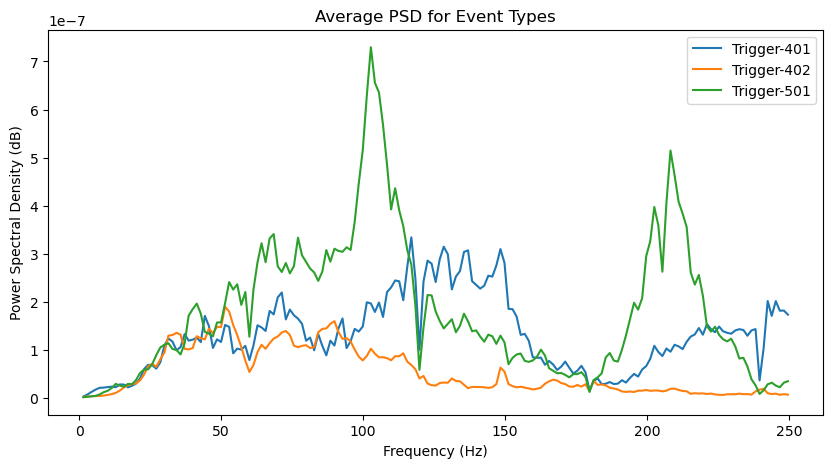

In [70]:

# Plot PSD comparison
plt.figure(figsize=(10, 5))
plt.plot(freqs, psd_event1.mean(axis=(0, 1)), label=event1)
plt.plot(freqs, psd_event2.mean(axis=(0, 1)), label=event2)
plt.plot(freqs, psd_event3.mean(axis=(0, 1)), label=event3)
plt.title("Average PSD for Event Types")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power Spectral Density (dB)")
plt.legend()
plt.show()

In [22]:
FREQ_BANDS = {
    "Delta": (1, 4),
    "Theta": (4, 8),
    "Alpha": (8, 13),
    "Beta": (13, 30),
    "Gamma": (30, 250),
}

# --- Functions ---
def compute_psd(epochs, fmin=1, fmax=250):
    """
    Compute PSD using Welch's method for all epochs.
    """
    data = epochs.get_data()  # Shape: (n_epochs, n_channels, n_times)
    sfreq = epochs.info["sfreq"]
    psd, freqs = [], None
    for ep in data:
        n_times = ep.shape[-1]
        n_fft = min(2048, n_times)
        psd_epoch, freqs = psd_array_welch(
            ep, sfreq=sfreq, fmin=fmin, fmax=fmax, n_fft=n_fft, n_overlap=n_fft // 2
        )
        psd.append(psd_epoch)
    psd = np.array(psd)  # Shape: (n_epochs, n_channels, n_freqs)
    return psd, freqs


def compute_band_psd(avg_psd, freqs, bands, ch_names):
    """
    Calculate mean PSD for defined frequency bands.
    """
    band_psd_df = pd.DataFrame(index=ch_names)
    for band, (fmin, fmax) in bands.items():
        band_indices = np.where((freqs >= fmin) & (freqs < fmax))[0]
        if len(band_indices) == 0:
            band_psd_df[band] = np.nan  # Handle empty frequency bands gracefully
        else:
            band_psd_df[band] = avg_psd[:, band_indices].mean(axis=1)
    band_psd_df.index.name = "Electrode"
    return band_psd_df


def process_subject(subject_id, bands, reshaped_data, save_dir=SAVE_DIR):
    """
    Process all `.fif` files for a subject, compute PSD, and reshape the data.
    """
    # Load all epochs for the subject
    epochs_list = load_epochs(subject_id, save_dir)

    # Process each `.fif` file (each representing an event type)
    for event_id, epochs in enumerate(epochs_list, start=1):
        ch_names = epochs.ch_names
        events, event_id_dict = get_events_from_epochs(epochs)

        # Check if any of the required triggers are missing for the current subject
        missing_triggers = False
        for condition in event_conditions:
            if condition not in event_id_dict:
                print(f"Warning: '{condition}' not found in event_id for subject {subject_id}. Skipping this trigger.")
                missing_triggers = True

        # If any triggers are missing, skip processing for this subject and move to next one
        if missing_triggers:
            continue
        
        # Compute PSD and average across epochs
        psd, freqs = compute_psd(epochs)
        avg_psd = psd.mean(axis=0)  # Shape: (n_channels, n_freqs)

        # Compute band-specific PSD
        band_psd_df = compute_band_psd(avg_psd, freqs, bands, ch_names)

        # Add event label
        band_psd_df["Event"] = event_id

        # Convert to long format
        long_format = band_psd_df.reset_index().melt(
            id_vars=["Electrode", "Event"], var_name="Frequency Band", value_name="Power"
        )

        # Create "Electrode x Frequency Band" feature
        long_format["Feature"] = long_format["Electrode"] + " x " + long_format["Frequency Band"]

        # Pivot to wide format
        wide_format = long_format.pivot_table(
            index="Event", columns="Feature", values="Power"
        ).reset_index()

        # Add Subject ID
        wide_format["Subject"] = subject_id

        # Append to reshaped data
        reshaped_data.append(wide_format)


# --- Main Processing Loop ---
reshaped_data = []

for subject_id in subject_ids:
    process_subject(subject_id, FREQ_BANDS, reshaped_data, save_dir=SAVE_DIR)

# Combine all reshaped data
final_reshaped_df = pd.concat(reshaped_data, ignore_index=True)

# Handle missing values (optional)
final_psd_df = final_reshaped_df.dropna(how="any", axis=1)  # Drop columns with NaN


Loaded 3 `.fif` files for sub-01.
Loaded 3 `.fif` files for sub-02.
Loaded 2 `.fif` files for sub-03.
Loaded 1 `.fif` files for sub-04.
Loaded 5 `.fif` files for sub-05.
Loaded 4 `.fif` files for sub-06.
Loaded 4 `.fif` files for sub-07.
Loaded 3 `.fif` files for sub-08.
Loaded 4 `.fif` files for sub-09.
Loaded 4 `.fif` files for sub-10.
Loaded 3 `.fif` files for sub-100.
Loaded 4 `.fif` files for sub-101.
Loaded 3 `.fif` files for sub-102.
Loaded 3 `.fif` files for sub-103.
Loaded 4 `.fif` files for sub-104.
Loaded 3 `.fif` files for sub-105.
Loaded 3 `.fif` files for sub-106.
Loaded 3 `.fif` files for sub-11.
Loaded 3 `.fif` files for sub-12.
Loaded 3 `.fif` files for sub-13.
Loaded 2 `.fif` files for sub-14.
Loaded 3 `.fif` files for sub-15.
Loaded 3 `.fif` files for sub-16.
Loaded 3 `.fif` files for sub-17.
Loaded 3 `.fif` files for sub-18.
Loaded 3 `.fif` files for sub-19.
Loaded 3 `.fif` files for sub-20.
Loaded 4 `.fif` files for sub-21.
Loaded 3 `.fif` files for sub-22.
Loaded 

In [23]:
final_psd_df = final_psd_df[['Subject'] + [col for col in final_psd_df.columns if col != 'Subject']]

final_psd_df

Feature,Subject,Event,POL DC01 x Alpha,POL DC01 x Beta,POL DC01 x Delta,POL DC01 x Gamma,POL DC01 x Theta,POL DC02 x Alpha,POL DC02 x Beta,POL DC02 x Delta,POL DC02 x Gamma,POL DC02 x Theta
0,sub-01,1,9.188124e-07,3.015262e-06,1.462661e-07,0.000008,4.666889e-07,2.306616e-09,2.104451e-09,1.659730e-09,1.100658e-08,1.851070e-09
1,sub-01,2,9.188124e-07,3.015262e-06,1.462661e-07,0.000008,4.666889e-07,2.306616e-09,2.104451e-09,1.659730e-09,1.100658e-08,1.851070e-09
2,sub-01,3,9.188124e-07,3.015262e-06,1.462661e-07,0.000008,4.666889e-07,2.306616e-09,2.104451e-09,1.659730e-09,1.100658e-08,1.851070e-09
3,sub-02,1,1.522002e-03,8.964400e-04,1.914480e-03,0.000027,1.703329e-03,3.018237e-09,2.721116e-09,2.528751e-09,1.145266e-08,2.910039e-09
4,sub-02,2,1.522002e-03,8.964400e-04,1.914480e-03,0.000027,1.703329e-03,3.018237e-09,2.721116e-09,2.528751e-09,1.145266e-08,2.910039e-09
...,...,...,...,...,...,...,...,...,...,...,...,...
113,sub-32,2,2.537134e-03,1.497095e-03,3.153415e-03,0.000045,2.836364e-03,4.173241e-09,3.466414e-09,4.060450e-09,1.086373e-08,5.005412e-09
114,sub-32,3,2.537134e-03,1.497095e-03,3.153415e-03,0.000045,2.836364e-03,4.173241e-09,3.466414e-09,4.060450e-09,1.086373e-08,5.005412e-09
115,sub-33,1,9.304855e-08,3.550788e-07,1.840076e-08,0.000002,3.534760e-08,2.756961e-09,1.612670e-08,2.069171e-09,4.824230e-07,2.297473e-09
116,sub-33,2,9.304855e-08,3.550788e-07,1.840076e-08,0.000002,3.534760e-08,2.756961e-09,1.612670e-08,2.069171e-09,4.824230e-07,2.297473e-09


## **Save the final datasets**    

- **Power Spectral Density (PSD)**: The frequency-domain features derived from the EEG data, offering insights into neural oscillations.

- **Event Epoch Features (EEF)**: The reshaped features related to specific event types and frequency bands, which are crucial for event-related brain activity analysis.


In [ ]:
# Save Power Spectral Density data 
final_psd_df.to_csv('ds005545_psd_df.csv', index=False)


# Save Event Epoch Features data 
final_reshaped_df.to_csv('ds005545_eef_df.csv', index=False)


print("Data saved successfully.")


Data saved successfully.
